In [39]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout



# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nlp-getting-started/sample_submission.csv
/kaggle/input/nlp-getting-started/train.csv
/kaggle/input/nlp-getting-started/test.csv


# Introduction
This purpose of this notebook is to participate in the "NLP with Disaster Tweets" competition on Kaggle. The primary objective is build a machine learning model using Natural Language Processing that is capable of doing a binary classification of tweets (Tweet is either about a natural disaster, or it is NOT about a natural disaster). 

The dataset provided by the competition consists of a set of training data and a set of test data. Each entry in the training set consists of an id, a keyword, a location, the raw text of the tweek, and a hand-assigned label (0 or 1). The test set omits the label, but otherwise includes the same features. 

# EDA

In [40]:
# Load the training and test datasets
train_df = pd.read_csv('/kaggle/input/nlp-getting-started/train.csv')
test_df = pd.read_csv('/kaggle/input/nlp-getting-started/test.csv')

# Display basic info
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (7613, 5)
Test shape: (3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [41]:
# Check data types and missing values
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [42]:
# Count nulls
print("Missing values in train:")
print(train_df.isnull().sum())

Missing values in train:
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


In [43]:
# Unique values in each column
print("Unique value counts:")
print(train_df.nunique())

Unique value counts:
id          7613
keyword      221
location    3341
text        7503
target         2
dtype: int64


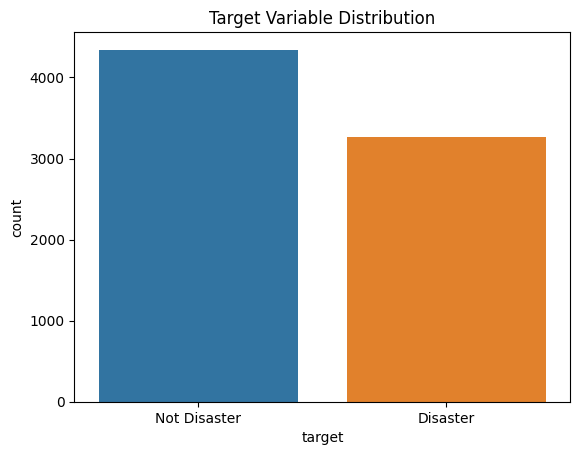

In [44]:
# Examine label
sns.countplot(data=train_df, x='target')
plt.title('Target Variable Distribution')
plt.xticks([0, 1], ['Not Disaster', 'Disaster'])
plt.show()

In [45]:
# Non-disaster samples
print("Non-disaster example:\n", train_df[train_df['target'] == 0]['text'].sample(1).values[0])
# Disaster samples
print("\nDisaster example:\n", train_df[train_df['target'] == 1]['text'].sample(1).values[0])

Non-disaster example:
 @KushWush I'm still traumatised by your driving. Having flashbacks of the lane hogging ??

Disaster example:
 Vacation update: my great aunt just killed a spider with her bare hand after I screamed in fear. #fierce


### Note:
ChatGPT (7/28/25) was used here to assist in generating ideas and code for additional EDA visualizations. "What are some potentially useful EDA visualizations for the NLP Disaster Tweets" kaggle competition?"

Text(0.5, 1.0, 'Top 20 Keywords in Training Set')

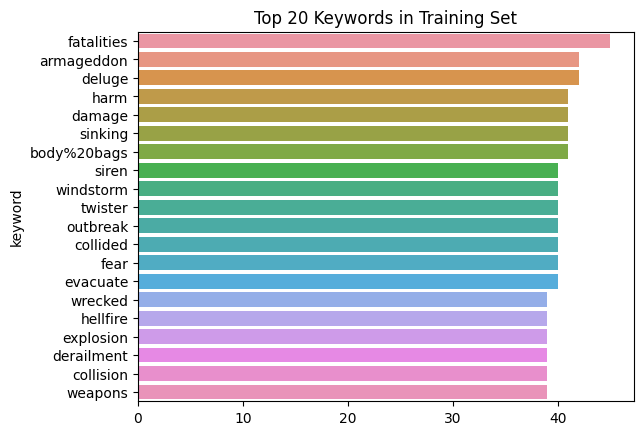

In [46]:
top_keywords = train_df['keyword'].value_counts().head(20)
sns.barplot(y=top_keywords.index, x=top_keywords.values)
plt.title("Top 20 Keywords in Training Set")

In [47]:
disaster_keywords = train_df[train_df['target'] == 1]['keyword'].value_counts().head(10)
print(disaster_keywords)

keyword
derailment           39
outbreak             39
wreckage             39
typhoon              37
oil%20spill          37
debris               37
suicide%20bombing    32
suicide%20bomb       32
evacuated            32
rescuers             32
Name: count, dtype: int64


In [48]:
non_disaster_keywords = train_df[train_df['target'] == 0]['keyword'].value_counts().head(10)
print(non_disaster_keywords)

keyword
body%20bags    40
armageddon     37
harm           37
wrecked        36
deluge         36
ruin           36
fear           35
twister        35
explode        35
siren          35
Name: count, dtype: int64


# Pre-Processing

We will do some basic pre-processing / data cleanup with the goal of preparing the data for a bi-directional RNN model. The bi-directional RNN allows for a fully context-aware approach (ie the entire tweet) rather than only being aware of PAST tokens at a given processing step. Essentially, we are saying that a specific word in a tweet may have a different meaning based on words that come before it OR after it. With a standard RNN, each step would only have the previous context which would likely limit our predictive power. 

* ChatGPT (7/28/25) was used to develop specific pre-processing steps suitable for the bd-rnn pipeline. "What pre-processing steps make sense for the dataset, given a bi-directional RNN model?"

In [49]:
def clean_tweet(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)         # Remove URLs
    text = re.sub(r"@\w+", "", text)                   # Remove mentions
    text = re.sub(r"\s+", " ", text).strip()           # Remove extra whitespace
    return text

# Apply to train and test
train_df['clean_text'] = train_df['text'].apply(clean_tweet)
test_df['clean_text'] = test_df['text'].apply(clean_tweet)

After lowercasing, removing @tags, urls, and extra whitespace, we need to prepare the data for processing by the model. Since the model cannot process raw text directly we need a way to convert the data to a numeric representation. Additionally, just like a standard neural network needs inputs of the same size/shape, so too does the RNN. Since tweets are of course not all the same length, we will also standardize the tweet length by choosing a specific length then padding shorter tweets with 0s and truncating longer length to the required size. 

In [50]:
vocab_size = 10000     # How many words to keep
max_len = 100          # Max number of tokens per tweet
oov_token = "<OOV>"    # Token for unknown words

# Initialize tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)

# Fit on training data (cleaned)
tokenizer.fit_on_texts(train_df['clean_text'])

# Convert train and test text to integer sequences
train_sequences = tokenizer.texts_to_sequences(train_df['clean_text'])
test_sequences = tokenizer.texts_to_sequences(test_df['clean_text'])

# Pad the sequences to uniform length
X_train_padded = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
X_test_padded = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

y_train = train_df['target'].values

# Build and Train Bi-Directional RNN

In [51]:
# Split the data
X_train, X_val, y_train_split, y_val = train_test_split(
    X_train_padded, y_train, test_size=0.2, random_state=42)

In [52]:
embedding_dim = 100

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [53]:
history = model.fit(
    X_train, y_train_split,
    epochs=5,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5761 - loss: 0.6712 - val_accuracy: 0.7886 - val_loss: 0.4893
Epoch 2/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8456 - loss: 0.3937 - val_accuracy: 0.7997 - val_loss: 0.4465
Epoch 3/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9044 - loss: 0.2620 - val_accuracy: 0.7905 - val_loss: 0.5009
Epoch 4/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9365 - loss: 0.1857 - val_accuracy: 0.7807 - val_loss: 0.5614
Epoch 5/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9547 - loss: 0.1370 - val_accuracy: 0.7794 - val_loss: 0.6310


# Analysis (Evaluate and Tune Model)

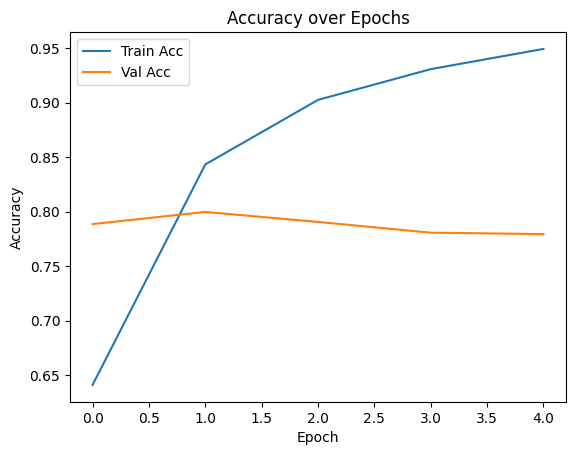

In [54]:
# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

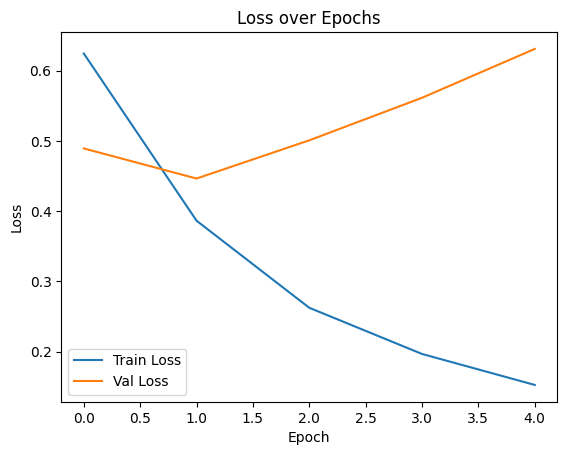

In [55]:
# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Based on the above accuracy and loss plots, we are seeing very clear overfitting. The training accuracy improves dramatically, reaching 95%, however the validation accuracy only slighly improves at first and then begins to fall slightly. Additionally, validation loss begins to rise sharply after the 2nd epoch. 

One simple approach to help alleviate over-fitting is simply stopping training early as soon as we see performance start to decrease on the validation data.

In [60]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

embedding_dim = 100

model2 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model2.summary()

history2 = model2.fit(
    X_train, y_train_split,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5902 - loss: 0.6605 - val_accuracy: 0.7597 - val_loss: 0.4828
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8492 - loss: 0.3873 - val_accuracy: 0.7833 - val_loss: 0.5805
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9004 - loss: 0.2633 - val_accuracy: 0.7846 - val_loss: 0.5165


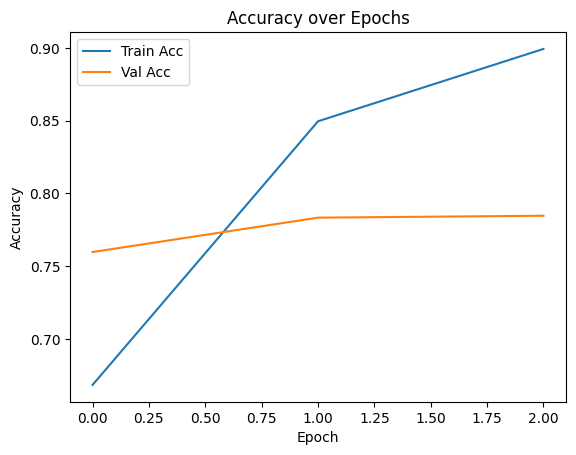

In [61]:
# Accuracy plot
plt.plot(history2.history['accuracy'], label='Train Acc')
plt.plot(history2.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

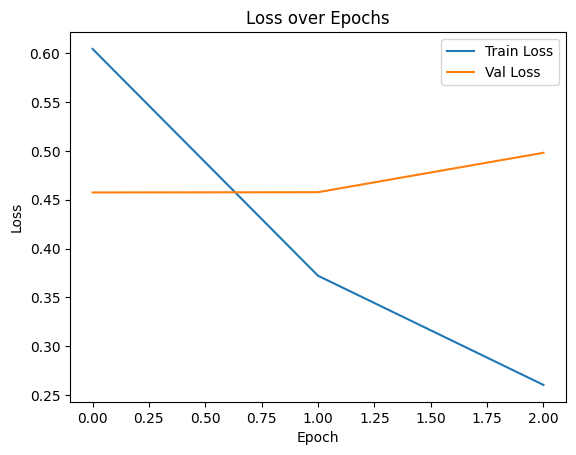

In [62]:
# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

This time our training stopped after just 2 epochs which resulted in slightly better performance on the validation set. (78.46% acc compared to 77.94% without early stopping).

Let's try improving the model further by adding L2 weight regularization. This will prevent the model from learning extremely large values for any one weight - effectively simplifying the model and hopefully reducing overfitting.


In [64]:
from tensorflow.keras import regularizers

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

embedding_dim = 100

model3 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)), # New L2 Regularization
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model3.summary()

history3 = model3.fit(
    X_train, y_train_split,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5925 - loss: 0.7094 - val_accuracy: 0.7853 - val_loss: 0.5204
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8450 - loss: 0.4261 - val_accuracy: 0.8043 - val_loss: 0.4764
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9005 - loss: 0.2904 - val_accuracy: 0.7938 - val_loss: 0.5056
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9400 - loss: 0.2107 - val_accuracy: 0.7866 - val_loss: 0.5853


L2 regularization resulted in only another very small gain in validation set accuracy. Now 76.66%. Let's try one more approach to reduce the overfitting - GloVe (Global Vectors for Word Representation). GloVe is a set of pretrained language/word vectors that have been trained on much large volumes of text data. This will hopefully lessen the amount of learning that our model has to do, and allow it to "focus" on learning weights that will specifically aid in our classification task. 

# GloVe
* ChatGPT (7/28/2025) was used to assist in adding the GloVe Embeddings. "How can I use GloVe to help reduce overfitting?"

In [71]:
# Load GloVe data (only once, so commented out for re-runs)
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

Archive:  glove.6B.zip.1
  inflating: glove.6B.50d.txt        
  inflating: glove.6B.100d.txt       
  inflating: glove.6B.200d.txt       
  inflating: glove.6B.300d.txt       


In [72]:
embedding_index = {}

# Load the glove data from the file-system
with open("glove.6B.100d.txt", encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coeffs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coeffs

print(f"Loaded {len(embedding_index)} word vectors.")

Loaded 400000 word vectors.


In [73]:
# Build an embedding matrix for the 
embedding_matrix = np.zeros((vocab_size, 100))  # 100 = embedding_dim
word_index = tokenizer.word_index

for word, i in word_index.items():
    if i < vocab_size:
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

In [75]:
from tensorflow.keras.layers import Embedding

embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=100,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False  # Freeze weights (optional)
)

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

model4 = Sequential([
    embedding_layer,
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(32, activation='relu',kernel_regularizer=regularizers.l2(0.001)), # L2 regularization
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model4.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model4.summary()

history4 = model4.fit(
    X_train, y_train_split,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6439 - loss: 0.6669 - val_accuracy: 0.8162 - val_loss: 0.4775
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7893 - loss: 0.5052 - val_accuracy: 0.8260 - val_loss: 0.4490
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8032 - loss: 0.4767 - val_accuracy: 0.8253 - val_loss: 0.4376
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8144 - loss: 0.4539 - val_accuracy: 0.8155 - val_loss: 0.4465
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8172 - loss: 0.4290 - val_accuracy: 0.8122 - val_loss: 0.4370
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8232 - loss: 0.4260 - val_accuracy: 0.8267 - val_loss: 0.4381
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8220 - loss: 0.4311 - val_accuracy: 0.8201 - val_loss: 0.4314
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8351 - loss: 0.4157 - val_accuracy: 0.8234 - v

Using GloVe resulted in a great improvement in our validation set accuracy - now up to 82.34% compared to our original 77.94% accuracy on the original model.  

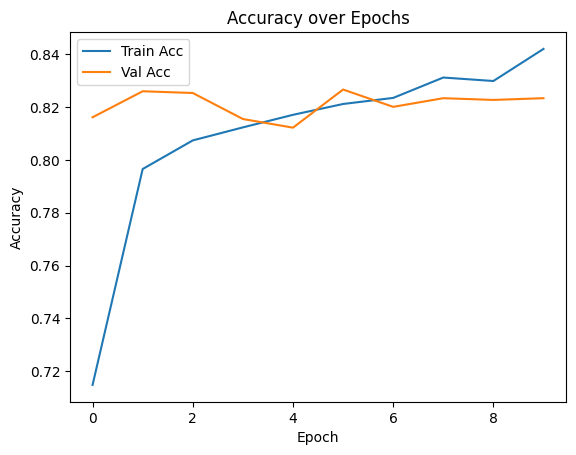

In [76]:
# Accuracy plot
plt.plot(history4.history['accuracy'], label='Train Acc')
plt.plot(history4.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

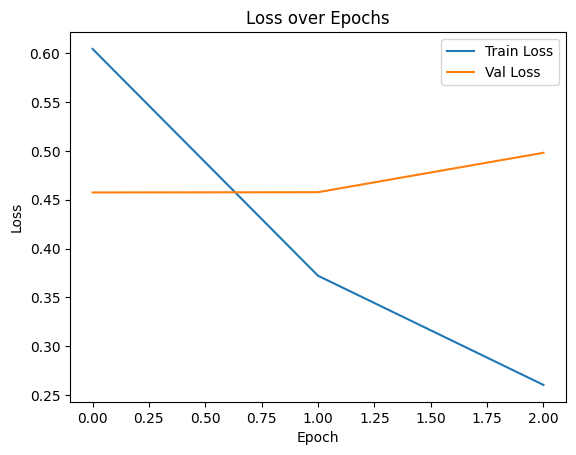

In [81]:
# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Create Submission

In [83]:
# Predict probabilities
test_preds = model4.predict(X_test_padded)

# Convert to binary labels (0 or 1)
test_labels = (test_preds > 0.5).astype(int).reshape(-1)

submission_df = pd.read_csv('/kaggle/input/nlp-getting-started/sample_submission.csv')
submission_df['target'] = test_labels

submission_df.to_csv('submission.csv', index=False)

102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


# References
* Bidirectional RNN In-Depth (https://medium.com/@fraidoonomarzai99/bidirectional-rnn-in-depth-1efd32c3cf46)
* ChatGPT (chatgpt.com)
* Multiple Kaggle submissions (https://www.kaggle.com/c/nlp-getting-started/code)